In [ ]:
!pip install -U transformers accelerate
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
small_model_name = "Qwen/Qwen3-1.7B"
small_tokenizer = AutoTokenizer.from_pretrained(small_model_name)
large_model_name = "Qwen/Qwen3-4B"
large_tokenizer = AutoTokenizer.from_pretrained(large_model_name)

## Load Data

In [4]:
from datasets import load_dataset

ds = load_dataset(
    "HuggingFaceFW/fineweb-edu",
    "default",
    split="train",
    streaming=True,
)

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

In [5]:
sequences = []

for example in ds:
    ids = small_tokenizer(
        example["text"],
        add_special_tokens=False,
    )["input_ids"]

    if len(ids) >= 1024:
        sequences.append(ids[:1024])

    if len(sequences) == 500:
        break

## Load Data

In [6]:
small_model = AutoModelForCausalLM.from_pretrained(small_model_name,torch_dtype="auto",device_map="auto")
large_model = AutoModelForCausalLM.from_pretrained(large_model_name,torch_dtype="auto",device_map="auto")


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [91]:
input_ids=sequences[0]
print(len(input_ids ))

1024


In [92]:
input_ids = torch.tensor(
    sequences[0],
    dtype=torch.long
).unsqueeze(0)

In [25]:
input_ids.shape

torch.Size([1, 1024])

In [42]:
with torch.no_grad():
    source_outputs = small_model(
        input_ids=input_ids.to(small_model.device),
        use_cache=True,
    )

    target_outputs = large_model(
        input_ids=input_ids.to(large_model.device),
        use_cache=True,
    )

In [43]:
source_cache = source_outputs.past_key_values
target_cache = target_outputs.past_key_values

print(len(source_cache.layers))#28 layer
print(len(target_cache.layers))#36 layer

28
36


## Examine Shapes

In [44]:
source_k = source_cache.layers[7].keys
source_v = source_cache.layers[7].values

target_k = target_cache.layers[10].keys
target_v = target_cache.layers[10].values

print("source K:", source_k.shape)
print("source V:", source_v.shape)

print("target K:", target_k.shape)
print("target V:", target_v.shape)#head_dim 128, 1024 sequence length, KV head 8 [batch, heads, sequence, head_dim]

source K: torch.Size([1, 8, 1024, 128])
source V: torch.Size([1, 8, 1024, 128])
target K: torch.Size([1, 8, 1024, 128])
target V: torch.Size([1, 8, 1024, 128])


In [46]:
source_layer = 7
target_layer = 10
head = 3

source_k = source_cache.layers[source_layer].keys
target_k = target_cache.layers[target_layer].keys

print("Full source:", source_k.shape)
print("Full target:", target_k.shape)

X = source_k[0, head, :, :]
Y = target_k[0, head, :, :]

print("Before stride:")
print("X:", X.shape)
print("Y:", Y.shape)

X = X[::4]
Y = Y[::4]

print("After stride:")
print("X:", X.shape)
print("Y:", Y.shape)

Full source: torch.Size([1, 8, 1024, 128])
Full target: torch.Size([1, 8, 1024, 128])
Before stride:
X: torch.Size([1024, 128])
Y: torch.Size([1024, 128])
After stride:
X: torch.Size([256, 128])
Y: torch.Size([256, 128])


## Example Linearity Check with single Head

In [96]:
#example r2 calc. with single head
all_X=[]
all_Y=[]
head=3
stride=4
source_layer = 14
target_layer = 14
for sequence in sequences[:20]:
    input_ids = torch.tensor(sequence,dtype=torch.long).unsqueeze(0)
    with torch.no_grad():
        source_outputs = small_model(
            input_ids=input_ids.to(small_model.device),
            use_cache=True,
        )
        target_outputs = large_model(
            input_ids=input_ids.to(large_model.device),
            use_cache=True,
        )
    source_cache = source_outputs.past_key_values
    target_cache = target_outputs.past_key_values
    
    source_k = source_cache.layers[source_layer].keys
    target_k = target_cache.layers[target_layer].keys

    X = source_k[0, head, :, :]
    Y = target_k[0, head, :, :]

    X = X[::stride]
    Y = Y[::stride]

    all_X.append(X.float().cpu())
    all_Y.append(Y.float().cpu())
X_k = torch.cat(all_X, dim=0)
Y_k = torch.cat(all_Y, dim=0)
X = X_k.float()
Y = Y_k.float()

X_aug = torch.cat(
    [X, torch.ones(X.shape[0], 1)],
    dim=1
)

solution = torch.linalg.lstsq(X_aug, Y).solution

W_k = solution[:-1]
b_k = solution[-1]
Y_k_pred = X @ W_k + b_k
ss_res = torch.sum((Y_k - Y_k_pred) ** 2)
ss_tot = torch.sum((Y_k - Y_k.mean()) ** 2)

r2_k = 1 - ss_res / ss_tot

print("Key R²:", r2_k.item())

Key R²: 0.6794108152389526


## Generating KV Caches with 50 Sequence

In [7]:
import torch

stride = 4
batch_size = 4

source_kv = []
target_kv = []

sequences = sequences[:50]

for start in range(0, len(sequences), batch_size):
    print(start)

    batch_sequences = sequences[start:start + batch_size]

    input_ids = torch.tensor(
        batch_sequences,
        dtype=torch.long
    )

    with torch.no_grad():
        source_outputs = small_model(
            input_ids=input_ids.to(small_model.device),
            use_cache=True,
        )

        target_outputs = large_model(
            input_ids=input_ids.to(large_model.device),
            use_cache=True,
        )

    source_cache = source_outputs.past_key_values
    target_cache = target_outputs.past_key_values

    batch_size_actual = len(batch_sequences)

    for b in range(batch_size_actual):

        source_seq = []
        target_seq = []

        for layer in range(28):
            source_k = source_cache.layers[layer].keys[
                b, :, ::stride, :
            ].float().cpu()

            source_v = source_cache.layers[layer].values[
                b, :, ::stride, :
            ].float().cpu()

            source_seq.append((source_k, source_v))

        for layer in range(36):
            target_k = target_cache.layers[layer].keys[
                b, :, ::stride, :
            ].float().cpu()

            target_v = target_cache.layers[layer].values[
                b, :, ::stride, :
            ].float().cpu()

            target_seq.append((target_k, target_v))

        source_kv.append(source_seq)
        target_kv.append(target_seq)

    del source_outputs
    del target_outputs
    del source_cache
    del target_cache

torch.save(source_kv, "/kaggle/working/source_kv_50.pt")
torch.save(target_kv, "/kaggle/working/target_kv_50.pt")


0
4
8
12
16
20
24
28
32
36
40
44
48


##  Example Layer Comparison

In [8]:
#layer_comparison 50 element ile headwise mean alınır
all_r2 = []

source_layer = 14
target_layer = 14

for head in range(8):

    all_X = []
    all_Y = []

    for i in range(50):
        X = source_kv[i][source_layer][0][head]
        Y = target_kv[i][target_layer][0][head]

        all_X.append(X)
        all_Y.append(Y)

    X = torch.cat(all_X, dim=0)
    Y = torch.cat(all_Y, dim=0)

    X_aug = torch.cat(
        [X, torch.ones(X.shape[0], 1)],
        dim=1
    )

    solution = torch.linalg.lstsq(X_aug, Y).solution

    W_k = solution[:-1]
    b_k = solution[-1]

    Y_k_pred = X @ W_k + b_k

    ss_res = torch.sum((Y - Y_k_pred) ** 2)
    ss_tot = torch.sum((Y - Y.mean()) ** 2)

    r2_k = 1 - ss_res / ss_tot

    all_r2.append(r2_k.item())

    print(f"Head {head} R²: {r2_k.item():.4f}")

print("Mean R²:", sum(all_r2) / len(all_r2))

Head 0 R²: 0.8095
Head 1 R²: 0.7333
Head 2 R²: 0.8016
Head 3 R²: 0.6715
Head 4 R²: 0.8091
Head 5 R²: 0.7827
Head 6 R²: 0.7491
Head 7 R²: 0.8017
Mean R²: 0.7698335498571396


## Layerwise Linearity Check

In [9]:
import torch

num_source_layers = 28
num_target_layers = 36
num_heads = 8

r2_matrix = torch.zeros(
    num_source_layers,
    num_target_layers
)

for source_layer in range(num_source_layers):

    for target_layer in range(num_target_layers):

        head_r2 = []

        for head in range(num_heads):

            all_X = []
            all_Y = []

            for i in range(50):

                X = source_kv[i][source_layer][0][head]
                Y = target_kv[i][target_layer][0][head]

                all_X.append(X)
                all_Y.append(Y)

            X = torch.cat(all_X, dim=0)
            Y = torch.cat(all_Y, dim=0)

            X_aug = torch.cat(
                [
                    X,
                    torch.ones(X.shape[0], 1)
                ],
                dim=1
            )

            solution = torch.linalg.lstsq(
                X_aug,
                Y
            ).solution

            W_k = solution[:-1]
            b_k = solution[-1]

            Y_pred = X @ W_k + b_k

            ss_res = torch.sum(
                (Y - Y_pred) ** 2
            )

            ss_tot = torch.sum(
                (Y - Y.mean()) ** 2
            )

            r2 = 1 - ss_res / ss_tot

            head_r2.append(r2.item())

        mean_r2 = sum(head_r2) / len(head_r2)

        r2_matrix[source_layer, target_layer] = mean_r2

        print(
            f"Source {source_layer:2d} → "
            f"Target {target_layer:2d}: "
            f"{mean_r2:.4f}"
        )


Source  0 → Target  0: 0.9612
Source  0 → Target  1: 0.8866
Source  0 → Target  2: 0.6032
Source  0 → Target  3: 0.6587
Source  0 → Target  4: 0.8509
Source  0 → Target  5: 0.8137
Source  0 → Target  6: 0.8222
Source  0 → Target  7: 0.4995
Source  0 → Target  8: 0.8326
Source  0 → Target  9: 0.4696
Source  0 → Target 10: 0.8042
Source  0 → Target 11: 0.7458
Source  0 → Target 12: 0.6535
Source  0 → Target 13: 0.3941
Source  0 → Target 14: 0.6854
Source  0 → Target 15: 0.4761
Source  0 → Target 16: 0.5222
Source  0 → Target 17: 0.4398
Source  0 → Target 18: 0.4239
Source  0 → Target 19: 0.5122
Source  0 → Target 20: 0.3861
Source  0 → Target 21: 0.4653
Source  0 → Target 22: 0.5934
Source  0 → Target 23: 0.5433
Source  0 → Target 24: 0.4095
Source  0 → Target 25: 0.6138
Source  0 → Target 26: 0.4614
Source  0 → Target 27: 0.5502
Source  0 → Target 28: 0.5222
Source  0 → Target 29: 0.4651
Source  0 → Target 30: 0.6392
Source  0 → Target 31: 0.4890
Source  0 → Target 32: 0.5745
Source  0 

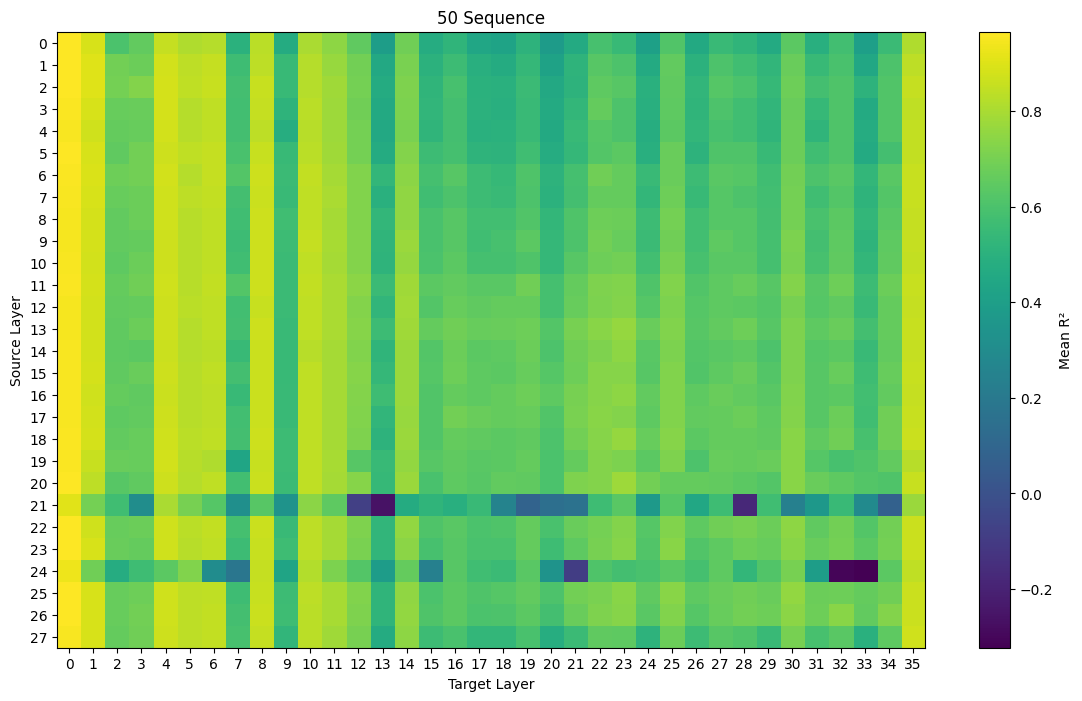

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

plt.imshow(
    r2_matrix.numpy(),
    aspect="auto"
)

plt.colorbar(label="Mean R²")

plt.xlabel("Target Layer")
plt.ylabel("Source Layer")

plt.xticks(range(36))
plt.yticks(range(28))

plt.title("50 Sequence")

plt.show()

## Headwise Linearity Check

In [12]:
best_matches = {}

for target_layer in range(36):

    scores = r2_matrix[:, target_layer]

    best_source_layer = torch.argmax(scores).item()
    best_r2 = scores[best_source_layer].item()

    best_matches[target_layer] = {
        "source_layer": best_source_layer,
        "r2": best_r2
    }

for target_layer, result in best_matches.items():

    print(
        f"Target layer {target_layer:2d} "
        f"<- Source layer {result['source_layer']:2d} "
        f"R² = {result['r2']:.4f}"
    )

Target layer  0 <- Source layer 25 R² = 0.9662
Target layer  1 <- Source layer  1 R² = 0.9039
Target layer  2 <- Source layer  2 R² = 0.6991
Target layer  3 <- Source layer  2 R² = 0.7260
Target layer  4 <- Source layer  3 R² = 0.8836
Target layer  5 <- Source layer  2 R² = 0.8448
Target layer  6 <- Source layer  2 R² = 0.8559
Target layer  7 <- Source layer  6 R² = 0.6190
Target layer  8 <- Source layer  6 R² = 0.8704
Target layer  9 <- Source layer  8 R² = 0.5731
Target layer 10 <- Source layer  9 R² = 0.8525
Target layer 11 <- Source layer 11 R² = 0.8050
Target layer 12 <- Source layer 11 R² = 0.7432
Target layer 13 <- Source layer 16 R² = 0.5665
Target layer 14 <- Source layer 12 R² = 0.7869
Target layer 15 <- Source layer 13 R² = 0.6604
Target layer 16 <- Source layer 17 R² = 0.6904
Target layer 17 <- Source layer 17 R² = 0.6711
Target layer 18 <- Source layer 13 R² = 0.6719
Target layer 19 <- Source layer 11 R² = 0.6885
Target layer 20 <- Source layer 16 R² = 0.6466
Target layer 

## Headwise Comparison

In [13]:
import torch

source_layer = 0
target_layer = 25

head_r2_matrix = torch.zeros(8, 8)

for source_head in range(8):

    for target_head in range(8):

        all_X = []
        all_Y = []

        for i in range(50):

            X = source_kv[i][source_layer][0][source_head]
            Y = target_kv[i][target_layer][0][target_head]

            all_X.append(X)
            all_Y.append(Y)

        X = torch.cat(all_X, dim=0).float()
        Y = torch.cat(all_Y, dim=0).float()

        X_aug = torch.cat(
            [X, torch.ones(X.shape[0], 1)],
            dim=1
        )

        solution = torch.linalg.lstsq(X_aug, Y).solution

        W = solution[:-1]
        b = solution[-1]

        Y_pred = X @ W + b

        ss_res = ((Y - Y_pred) ** 2).sum()
        ss_tot = ((Y - Y.mean()) ** 2).sum()

        r2 = 1 - ss_res / ss_tot

        head_r2_matrix[source_head, target_head] = r2.item()

print(head_r2_matrix)

tensor([[0.6698, 0.6998, 0.3725, 0.7542, 0.6974, 0.6123, 0.6153, 0.5570],
        [0.6738, 0.7087, 0.3665, 0.7784, 0.7074, 0.6106, 0.6150, 0.5252],
        [0.6217, 0.6402, 0.3532, 0.7356, 0.6605, 0.5831, 0.5884, 0.5393],
        [0.6691, 0.6948, 0.3672, 0.7616, 0.7001, 0.6101, 0.6107, 0.5575],
        [0.6818, 0.7152, 0.3705, 0.7749, 0.7162, 0.6155, 0.5512, 0.5553],
        [0.6773, 0.6957, 0.3878, 0.7564, 0.6373, 0.6229, 0.5515, 0.5784],
        [0.6137, 0.6217, 0.3354, 0.7076, 0.6423, 0.5698, 0.5784, 0.5285],
        [0.6663, 0.6897, 0.3591, 0.7560, 0.6569, 0.5374, 0.6037, 0.5477]])


## Select best Source Heads for Reconstruction

In [14]:
for target_head in range(8):

    scores = head_r2_matrix[:, target_head]

    best_source_head = torch.argmax(scores).item()
    best_r2 = scores[best_source_head].item()

    print(
        f"Target head {target_head} "
        f"<- Source head {best_source_head} "
        f"R² = {best_r2:.4f}"
    )

Target head 0 <- Source head 4 R² = 0.6818
Target head 1 <- Source head 4 R² = 0.7152
Target head 2 <- Source head 5 R² = 0.3878
Target head 3 <- Source head 1 R² = 0.7784
Target head 4 <- Source head 4 R² = 0.7162
Target head 5 <- Source head 5 R² = 0.6229
Target head 6 <- Source head 0 R² = 0.6153
Target head 7 <- Source head 5 R² = 0.5784


In [17]:
import torch

source_layer = 0
target_layer = 25

source_head = 1
target_head = 3

alpha = 0.1

all_X = []
all_Y = []

for i in range(50):

    X = source_kv[i][source_layer][0][source_head]
    Y = target_kv[i][target_layer][0][target_head]

    all_X.append(X)
    all_Y.append(Y)

X = torch.cat(all_X, dim=0).float()
Y = torch.cat(all_Y, dim=0).float()

X_aug = torch.cat(
    [X, torch.ones(X.shape[0], 1)],
    dim=1
)

n_features = X_aug.shape[1]

I = torch.eye(n_features)

I[-1, -1] = 0

W_full = torch.linalg.solve(
    X_aug.T @ X_aug + alpha * I,
    X_aug.T @ Y
)

W = W_full[:-1]
b = W_full[-1]

Y_pred = X @ W + b

print("W shape:", W.shape)
print("b shape:", b.shape)

W shape: torch.Size([128, 128])
b shape: torch.Size([128])
R²: 0.7821422219276428


In [12]:
import torch

stride = 4
batch_size = 4

source_kv = []
target_kv = []

sequences = sequences[:100]

for start in range(0, len(sequences), batch_size):
    print(start)

    batch_sequences = sequences[start:start + batch_size]

    input_ids = torch.tensor(
        batch_sequences,
        dtype=torch.long
    )

    with torch.no_grad():
        source_outputs = small_model(
            input_ids=input_ids.to(small_model.device),
            use_cache=True,
        )

        target_outputs = large_model(
            input_ids=input_ids.to(large_model.device),
            use_cache=True,
        )

    source_cache = source_outputs.past_key_values
    target_cache = target_outputs.past_key_values

    batch_size_actual = len(batch_sequences)

    for b in range(batch_size_actual):

        source_seq = []
        target_seq = []

        for layer in range(28):
            source_k = source_cache.layers[layer].keys[
                b, :, ::stride, :
            ].float().cpu()

            source_v = source_cache.layers[layer].values[
                b, :, ::stride, :
            ].float().cpu()

            source_seq.append((source_k, source_v))

        for layer in range(36):
            target_k = target_cache.layers[layer].keys[
                b, :, ::stride, :
            ].float().cpu()

            target_v = target_cache.layers[layer].values[
                b, :, ::stride, :
            ].float().cpu()

            target_seq.append((target_k, target_v))

        source_kv.append(source_seq)
        target_kv.append(target_seq)

    del source_outputs
    del target_outputs
    del source_cache
    del target_cache

torch.save(source_kv, "/kaggle/working/source_kv_100.pt")
torch.save(target_kv, "/kaggle/working/target_kv_100.pt")

print("Saved.")

0
4
8
12
16
20
24
28
32
36
40
44
48


In [ ]:
#sequence 100 elementli layer karşılaştırma
all_r2 = []

source_layer = 14
target_layer = 14

for head in range(8):

    all_X = []
    all_Y = []

    for i in range(100):
        X = source_kv[i][source_layer][0][head]
        Y = target_kv[i][target_layer][0][head]

        all_X.append(X)
        all_Y.append(Y)

    X = torch.cat(all_X, dim=0)
    Y = torch.cat(all_Y, dim=0)

    X_aug = torch.cat(
        [X, torch.ones(X.shape[0], 1)],
        dim=1
    )

    solution = torch.linalg.lstsq(X_aug, Y).solution

    W_k = solution[:-1]
    b_k = solution[-1]

    Y_k_pred = X @ W_k + b_k

    ss_res = torch.sum((Y - Y_k_pred) ** 2)
    ss_tot = torch.sum((Y - Y.mean()) ** 2)

    r2_k = 1 - ss_res / ss_tot

    all_r2.append(r2_k.item())

    print(f"Head {head} R²: {r2_k.item():.4f}")

print("Mean R²:", sum(all_r2) / len(all_r2))

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

plt.imshow(
    r2_matrix.numpy(),
    aspect="auto"
)

plt.colorbar(label="Mean R²")

plt.xlabel("Target Layer")
plt.ylabel("Source Layer")

plt.xticks(range(36))
plt.yticks(range(28))

plt.title("100 Sequence")

plt.show()